<a href="https://colab.research.google.com/github/Ronaldo-Junior1/analise-dados-atividade2/blob/main/RandomForestRegressor_SupportVectorRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dicionário das variáveis**

* **Data** : Identifica a Sazonalidade daquela Temperatura
* **Hora** : Identifica a Hora que a Temperatura foi Registrada
* **Pressao** : Pressão no momento de registro da Temperatura
* **Radiacao** : Radiação no momento de registro da Temperatura
* **Temp_Inst** : Temperatura Registrada
* **Pto_Orvalho_Inst** : Ponto de Orvalho no momento de registro da Temperatura
* **Umid_Inst** : Umidade no momento de registro da Temperatura
* **Vento_Vel** : Velocidade do Vento no momento de registro da Temperatura

# Importando Pacotes Necessários

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [18]:
boston = fetch_openml(name="Boston", version=1, as_frame=True,parser='pandas' )
X = boston.data.astype(float)
y = boston.target.astype(float)

In [19]:
sns.set_theme(style="whitegrid", palette='rocket')
#sns.color_palette("flare", as_cmap=True)

In [20]:
#. Importando Base de Dados
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Analise_dados"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configurando Base de Dados

In [21]:
column_names = [
    'data', 'hora', 'pressao', 'radiacao', 'temp_inst' , 'pto_orvalho_inst',
    'umid_inst', 'vento_vel'
]
df = pd.read_csv(f'{path}/A519.csv', sep=';', encoding='latin1')

In [22]:
print(df.columns)

Index(['data', 'hora', 'pressao', 'radiacao', 'temp_inst', 'pto_orvalho_inst',
       'umid_inst', 'vento_vel', 'Unnamed: 8'],
      dtype='object')


In [23]:
df = df.drop(columns='Unnamed: 8')

In [24]:
df.columns = column_names

# Análise Exploratória/Limpeza dos Dados

In [25]:
df.head(10)

,data,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel
0,2013-12-03,0,949.3,-3.540,22.3,21.0,92.0,2.3
1,2013-12-03,100,949.7,-3.540,22.1,20.6,91.0,2.1
2,2013-12-03,200,949.4,-3.540,22.1,20.0,88.0,1.3
3,2013-12-03,300,949.1,-3.540,21.9,20.2,90.0,2.3
4,2013-12-03,400,948.6,-3.540,21.4,19.8,91.0,1.5
5,2013-12-03,500,947.8,-3.540,21.2,19.8,92.0,2.0
6,2013-12-03,600,947.3,-3.540,20.8,19.4,92.0,1.8
7,2013-12-03,700,947.7,-3.540,20.4,19.6,95.0,1.7
8,2013-12-03,800,948.3,-3.445,20.4,19.7,95.0,1.8
9,2013-12-03,900,949.2,38.054,20.6,19.8,95.0,1.9


In [26]:
df.shape

(83232, 8)

- Podemos ver que nosso DataSet possui mais de 83 mil registros, o que é uma quantidade significativa de dados

In [27]:
df.describe()

,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel
count,83232.000000,77953.000000,77953.000000,77953.000000,77948.000000,77947.000000,77953.000000
mean,1150.000000,950.645189,854.659699,24.266163,15.971423,64.328492,1.797509
std,692.222814,3.183373,1127.039563,5.117659,4.969063,21.084565,1.377348
min,0.000000,938.900000,-3.540000,2.000000,-10.000000,8.000000,0.000000
25%,575.000000,948.500000,-3.529000,21.000000,12.500000,49.000000,0.800000
50%,1150.000000,950.500000,79.662000,23.600000,17.300000,67.000000,1.500000
75%,1725.000000,952.700000,1727.162000,28.100000,19.800000,82.000000,2.500000
max,2300.000000,963.000000,4291.431000,40.900000,33.200000,100.000000,10.300000


- Podemos ver que nosso DataSet possui outliers. Já que, 75% dos dados estão abaixo de 28°C. Mas, o máximo registrado é de aproximadamente 40°C, sendo um valor muito alto em comparação com os demais valores registrados.

In [28]:
df.dtypes

,0
data,object
hora,int64
pressao,float64
radiacao,float64
temp_inst,float64
pto_orvalho_inst,float64
umid_inst,float64
vento_vel,float64


- Aqui podemos ver que a variável Data está no formato errado. Será preciso corrigir isso futuramente

In [29]:
((df.isnull().sum() / df.shape[0])*100).sort_values(ascending=False)

,0
umid_inst,6.349721
pto_orvalho_inst,6.348520
radiacao,6.342512
pressao,6.342512
temp_inst,6.342512
vento_vel,6.342512
data,0.000000
hora,0.000000


- Podemos ver que nosso DataSet possui dados nulos.

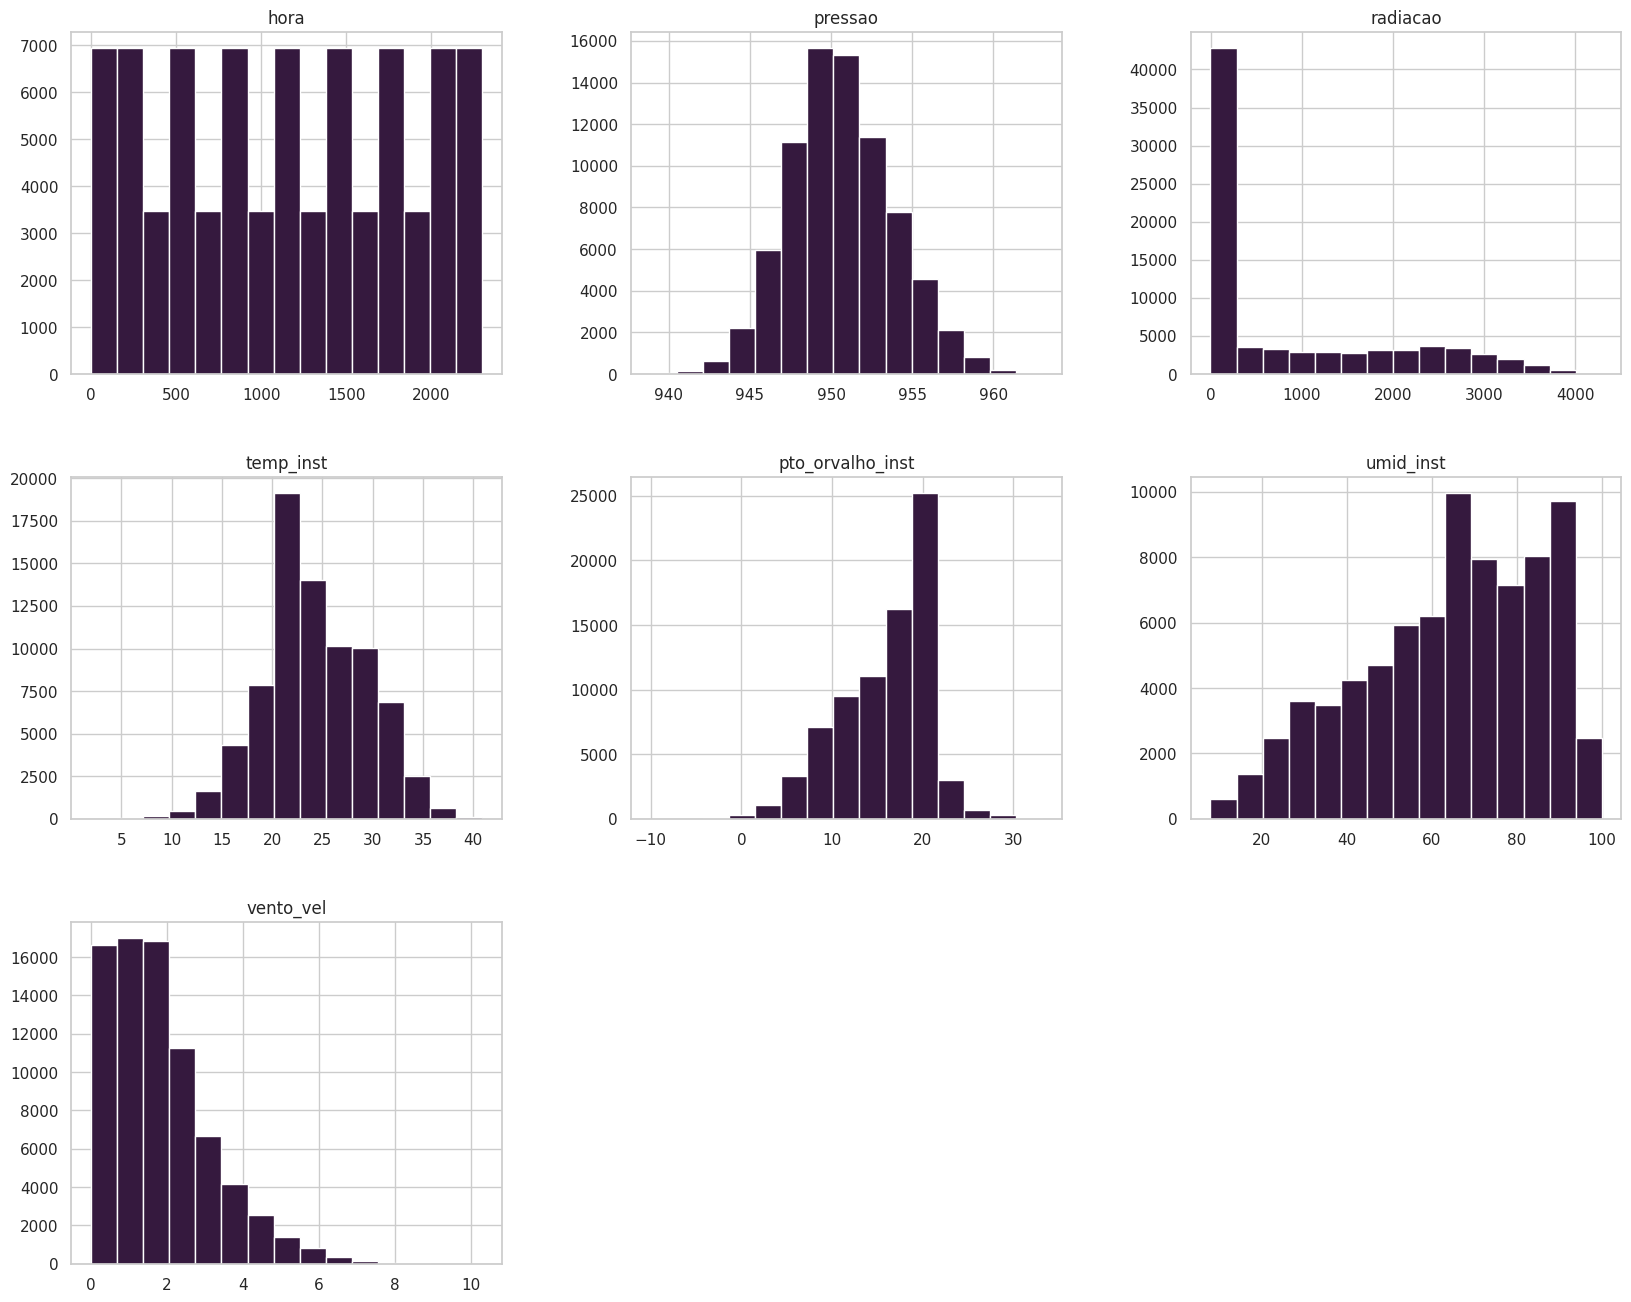

In [30]:
df.hist(bins=15, figsize=(20,16));

- Podemos ver que as variáveis temperatura e pressão possuim uma distribuição próxima de uma distribuição normal. Já as outras variáveis, não apresentam uma distribuição normal.

- Após uma breve análise dos dados, será necessário fazer algumas alterações/modificações para que se obtenha uma maior eficiência dos algoritmos

In [31]:
#. Transformando a coluna Data para seu tipo correto:
df['data'] = pd.to_datetime(df['data'])

#. Removendo valores Nulos
df.dropna(inplace=True)

#. Criando uma nova coluna para armazenar as horas convertidas, para uma melhor manipulação da variável
df['hora_int'] = df['hora'] // 100

#. criando uma nova coluna para armazenar os valores corrigidos da radiação (Sem valores negativos)
df['radiacao_clip'] = df['radiacao'].clip(lower=0)

#. Transformando Hora em SEN e COS para que a continuidade circular (24h) seja preservada
df['hora_sin'] = np.sin(2 * np.pi * df['hora_int'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora_int'] / 24)

#. Plicando a mesma regra de SEN e COS para manter a continuidade anual (12 meses)
df['mes'] = df['data'].dt.month
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

- Agora vamos preparar nosso DataSet para o treinamento dos Algoritmos

In [32]:
#. Separando as variáveis que serão utilizadas
features = [
    'pressao',          # Pressão atmosférica
    'radiacao_clip',    # Radiação solar (clipada em 0)
    'pto_orvalho_inst', # Ponto de orvalho
    'umid_inst',        # Umidade relativa
    'vento_vel',        # Velocidade do vento
    'hora_sin',         # Componente seno do ciclo diário
    'hora_cos',         # Componente cosseno do ciclo diário
    'mes_sin',          # Componente seno do ciclo anual
    'mes_cos'           # Componente cosseno do ciclo anual
]

#. Definindo a variável a qual queremos prever
target = 'temp_inst'

X = df[features]
y = df[target]
print(f'\nX: {X.shape} | y: {y.shape}')


X: (77945, 9) | y: (77945,)


# Random Forest Regressor

In [47]:
#. Separação da quantidade de dados para treino e para teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#. Dicionário para armazenamento dos resultados
resultados_rf = []

## Testes com variações de valores do N_Estimators (Número de Árvores)

In [48]:
#. Aqui estamos configurando o Modelo para o primeiro teste com apenas 10 árvores
modelo = RandomForestRegressor(
    n_estimators=10,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

#. Aqui vamos rodar um cronômetro para verificar quanto tempo o modelo precisa para aprender com essas configurações
inicio = time.perf_counter()

modelo.fit(X_train, y_train)

fim = time.perf_counter()

tempo_execucao = fim - inicio

#. Aplicando o modelo aos dados testes
y_pred = modelo.predict(X_test)

#. Métricas para Avaliação
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

resultados_rf.append({
    'Teste': 'RF-1',
    'n_estimators': 10,
    'max_features': 'sqrt',
    'bootstrap': True,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'Tempo (s)': tempo_execucao
})

#. Resultados
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")
print(f"Tempo de treinamento: {tempo_execucao:.4f} segundos")

MAE : 0.4803
RMSE: 0.7281
R²  : 0.9798
Tempo de treinamento: 3.3290 segundos


In [49]:
resultados_rf

[{'Teste': 'RF-1',
  'n_estimators': 10,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.4802668548335365,
  'RMSE': 0.7281468675143675,
  'R2': 0.9797916029688795,
  'Tempo (s)': 3.329024593998838}]

- Após observar os resultados desse modelo. Podemos ver que, mesmo com poucas árvores (10), tivemos bons resultados. Nosso modelo, errou, em geral por aproximadamente 0,5°C (MAE). Entretanto, caso os erros grandes fossem mais penalizados ele teria uma taxa de erro de aproximadamente 0,7°C. Ainda sim, o modelo conseguiu explicar cerca de 97% dos dados presentes na divisão de teste com base em seu treinamento. Isso tudo consumindo pouco recurso computacional, já que o treinamento foi concluido em aproximadamente 3 segundos. Agora precisamos verificar se esses números irão mudar drasticamente ao aumentar o número de árvores.

In [50]:
#. Aqui estamos configurando o Modelo para o primeiro teste com apenas 100 árvores
modelo = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

#. Aqui vamos rodar um cronômetro para verificar quanto tempo o modelo precisa para aprender com essas configurações
inicio = time.perf_counter()

modelo.fit(X_train, y_train)

fim = time.perf_counter()

tempo_execucao = fim - inicio

#. Aplicando o modelo aos dados testes
y_pred = modelo.predict(X_test)

#. Métricas para Avaliação
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

resultados_rf.append({
    'Teste': 'RF-2',
    'n_estimators': 100,
    'max_features': 'sqrt',
    'bootstrap': True,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'Tempo (s)': tempo_execucao
})

#. Resultados
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")
print(f"Tempo de treinamento: {tempo_execucao:.4f} segundos")

MAE : 0.3884
RMSE: 0.6070
R²  : 0.9860
Tempo de treinamento: 19.2663 segundos


In [51]:
resultados_rf

[{'Teste': 'RF-1',
  'n_estimators': 10,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.4802668548335365,
  'RMSE': 0.7281468675143675,
  'R2': 0.9797916029688795,
  'Tempo (s)': 3.329024593998838},
 {'Teste': 'RF-2',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.9859574839132138,
  'Tempo (s)': 19.266285275998598}]

- Após a aplicação de 100 árvores no modelo, podemos ver que o modelo está chegando mais próximo da temperatura real, errando apenas por 0,38°C (MAE). Está cometendo menos erros graves, já que a penalidade para esses tipos de erros diminuiu (RMSE) e conseguiu explicar 98% dos dados do teste. Entratanto, o tempo de treinamento foi muito maior em relação ao das 10 árvores e o retorno em precisão não teve um aumento que justificasse todo esse gasto computacional. Ou seja, aparentemente, só aumentar o número de árvores não garante a precisão do modelo. Vamos testar com um número de árvores muito maior para validar essa hipótese.

In [52]:
#. Aqui estamos configurando o Modelo para o primeiro teste com apenas 500 árvores
modelo = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

#. Aqui vamos rodar um cronômetro para verificar quanto tempo o modelo precisa para aprender com essas configurações
inicio = time.perf_counter()

modelo.fit(X_train, y_train)

fim = time.perf_counter()

tempo_execucao = fim - inicio

#. Aplicando o modelo aos dados testes
y_pred = modelo.predict(X_test)

#. Métricas para Avaliação
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

resultados_rf.append({
    'Teste': 'RF-3',
    'n_estimators': 500,
    'max_features': 'sqrt',
    'bootstrap': True,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'Tempo (s)': tempo_execucao
})

#. Resultados
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")
print(f"Tempo de treinamento: {tempo_execucao:.4f} segundos")

MAE : 0.3768
RMSE: 0.5919
R²  : 0.9866
Tempo de treinamento: 96.4660 segundos


In [53]:
resultados_rf

[{'Teste': 'RF-1',
  'n_estimators': 10,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.4802668548335365,
  'RMSE': 0.7281468675143675,
  'R2': 0.9797916029688795,
  'Tempo (s)': 3.329024593998838},
 {'Teste': 'RF-2',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.9859574839132138,
  'Tempo (s)': 19.266285275998598},
 {'Teste': 'RF-3',
  'n_estimators': 500,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.37684222675329593,
  'RMSE': 0.5918791689750081,
  'R2': 0.986647579357582,
  'Tempo (s)': 96.4660169660001}]

- Após testar com 500 árvores, podemos ver que nosso modelo aparenta ter chegado ao seu teto de eficiênica, já que não tivemos melhorias tão significativas quanto foi das 10 para 100 árvores. Já que os resultados estão muito próximos. A única diferença entre o modelo com 100 e 500 árvores é o consumo computacional, que foi muito maior e levou muito mais tempo, que não justifica os resultados obtidos. Portanto, Podemos ver que um bom valor para o número de árvores geradas seja de 100. Agora, para ter um nível de precisão mais eficiente será necessário combinar esse número de árvores com os demais parâmetros.

## Testes com variações de valores do max_features (Número de Atributos para Treinamento)

In [54]:
#. Aqui estamos configurando o Modelo para o primeiro teste com apenas 1 atributo
modelo = RandomForestRegressor(
    n_estimators=100,
    max_features=1,
    bootstrap=True,
    random_state=42
)

#. Aqui vamos rodar um cronômetro para verificar quanto tempo o modelo precisa para aprender com essas configurações
inicio = time.perf_counter()

modelo.fit(X_train, y_train)

fim = time.perf_counter()

tempo_execucao = fim - inicio

#. Aplicando o modelo aos dados testes
y_pred = modelo.predict(X_test)

#. Métricas para Avaliação
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

resultados_rf.append({
    'Teste': 'RF-4',
    'n_estimators': 100,
    'max_features': 1,
    'bootstrap': True,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'Tempo (s)': tempo_execucao
})

#. Resultados
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")
print(f"Tempo de treinamento: {tempo_execucao:.4f} segundos")

MAE : 0.7493
RMSE: 1.0483
R²  : 0.9581
Tempo de treinamento: 12.8730 segundos


In [55]:
resultados_rf

[{'Teste': 'RF-1',
  'n_estimators': 10,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.4802668548335365,
  'RMSE': 0.7281468675143675,
  'R2': 0.9797916029688795,
  'Tempo (s)': 3.329024593998838},
 {'Teste': 'RF-2',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.9859574839132138,
  'Tempo (s)': 19.266285275998598},
 {'Teste': 'RF-3',
  'n_estimators': 500,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.37684222675329593,
  'RMSE': 0.5918791689750081,
  'R2': 0.986647579357582,
  'Tempo (s)': 96.4660169660001},
 {'Teste': 'RF-4',
  'n_estimators': 100,
  'max_features': 1,
  'bootstrap': True,
  'MAE': 0.7492593966046412,
  'RMSE': 1.0482910370587306,
  'R2': 0.9581150848571747,
  'Tempo (s)': 12.872951837998698}]

- Aqui podemos ver que essa variação de Modelo foi muito ruim. Errando por 0,7°C (MAE). Tendo uma penalidade de erros graves de 1 (RMSE) e conseguiu explicar somente 95% dos dados. Dessa forma, podemos ver que a quantidade de atributos que as árvores usam para suas decisões é importante para se obter uma boa previsibilidade.

In [56]:
#. Aqui estamos configurando o Modelo para o primeiro teste com o quadrado dos atributos
modelo = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

#. Aqui vamos rodar um cronômetro para verificar quanto tempo o modelo precisa para aprender com essas configurações
inicio = time.perf_counter()

modelo.fit(X_train, y_train)

fim = time.perf_counter()

tempo_execucao = fim - inicio

#. Aplicando o modelo aos dados testes
y_pred = modelo.predict(X_test)

#. Métricas para Avaliação
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

resultados_rf.append({
    'Teste': 'RF-5',
    'n_estimators': 100,
    'max_features': 'sqrt',
    'bootstrap': True,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'Tempo (s)': tempo_execucao
})

#. Resultados
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")
print(f"Tempo de treinamento: {tempo_execucao:.4f} segundos")

MAE : 0.3884
RMSE: 0.6070
R²  : 0.9860
Tempo de treinamento: 19.4107 segundos


In [57]:
resultados_rf

[{'Teste': 'RF-1',
  'n_estimators': 10,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.4802668548335365,
  'RMSE': 0.7281468675143675,
  'R2': 0.9797916029688795,
  'Tempo (s)': 3.329024593998838},
 {'Teste': 'RF-2',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.9859574839132138,
  'Tempo (s)': 19.266285275998598},
 {'Teste': 'RF-3',
  'n_estimators': 500,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.37684222675329593,
  'RMSE': 0.5918791689750081,
  'R2': 0.986647579357582,
  'Tempo (s)': 96.4660169660001},
 {'Teste': 'RF-4',
  'n_estimators': 100,
  'max_features': 1,
  'bootstrap': True,
  'MAE': 0.7492593966046412,
  'RMSE': 1.0482910370587306,
  'R2': 0.9581150848571747,
  'Tempo (s)': 12.872951837998698},
 {'Teste': 'RF-5',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.985

- Aqui podemos ver que houve um bom resultado, como esperado, já que testamos essa mesma variante quando estavamos verificando o número de árvores. Entãos, vamos verificar se com todas as variáveis o modelo consegue ter uma eficiência ainda maior.

In [58]:
#. Aqui estamos configurando o Modelo para o primeiro teste com todos os atributos
modelo = RandomForestRegressor(
    n_estimators=100,
    max_features=None,
    bootstrap=True,
    random_state=42
)

#. Aqui vamos rodar um cronômetro para verificar quanto tempo o modelo precisa para aprender com essas configurações
inicio = time.perf_counter()

modelo.fit(X_train, y_train)

fim = time.perf_counter()

tempo_execucao = fim - inicio

#. Aplicando o modelo aos dados testes
y_pred = modelo.predict(X_test)

#. Métricas para Avaliação
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

resultados_rf.append({
    'Teste': 'RF-6',
    'n_estimators': 100,
    'max_features': None,
    'bootstrap': True,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'Tempo (s)': tempo_execucao
})

#. Resultados
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")
print(f"Tempo de treinamento: {tempo_execucao:.4f} segundos")

MAE : 0.1539
RMSE: 0.2866
R²  : 0.9969
Tempo de treinamento: 42.6771 segundos


In [59]:
resultados_rf

[{'Teste': 'RF-1',
  'n_estimators': 10,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.4802668548335365,
  'RMSE': 0.7281468675143675,
  'R2': 0.9797916029688795,
  'Tempo (s)': 3.329024593998838},
 {'Teste': 'RF-2',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.9859574839132138,
  'Tempo (s)': 19.266285275998598},
 {'Teste': 'RF-3',
  'n_estimators': 500,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.37684222675329593,
  'RMSE': 0.5918791689750081,
  'R2': 0.986647579357582,
  'Tempo (s)': 96.4660169660001},
 {'Teste': 'RF-4',
  'n_estimators': 100,
  'max_features': 1,
  'bootstrap': True,
  'MAE': 0.7492593966046412,
  'RMSE': 1.0482910370587306,
  'R2': 0.9581150848571747,
  'Tempo (s)': 12.872951837998698},
 {'Teste': 'RF-5',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.985

- Aqui podemos ver que os atributos ajudaram muito para a eficiência do modelo. Ao se utilizar todos, podemos ver que o erro de temperatura foi muito baixo (MAE) de 0,15°C uma penalidade de erros graves de 0,3, aproximadamente, (RMSE) e conseguiu explicar cerca de 99% dos dados. Embora tenha demorado um pouco mais para ser concluído, foi um custo computacional que valeu a pena tendo em vista o resultado obtido.

## Testes com variações de valores do bootstrap (Se as árvores recebem conjunto de dados diferentes ou não)

In [60]:
#. Aqui estamos configurando o Modelo para o primeiro teste recebendo conjunto de dados diferentes
modelo = RandomForestRegressor(
    n_estimators=100,
    max_features=None,
    bootstrap=True,
    random_state=42
)

#. Aqui vamos rodar um cronômetro para verificar quanto tempo o modelo precisa para aprender com essas configurações
inicio = time.perf_counter()

modelo.fit(X_train, y_train)

fim = time.perf_counter()

tempo_execucao = fim - inicio

#. Aplicando o modelo aos dados testes
y_pred = modelo.predict(X_test)

#. Métricas para Avaliação
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

resultados_rf.append({
    'Teste': 'RF-7',
    'n_estimators': 100,
    'max_features': None,
    'bootstrap': True,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'Tempo (s)': tempo_execucao
})

#. Resultados
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")
print(f"Tempo de treinamento: {tempo_execucao:.4f} segundos")

MAE : 0.1539
RMSE: 0.2866
R²  : 0.9969
Tempo de treinamento: 42.6459 segundos


In [61]:
resultados_rf

[{'Teste': 'RF-1',
  'n_estimators': 10,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.4802668548335365,
  'RMSE': 0.7281468675143675,
  'R2': 0.9797916029688795,
  'Tempo (s)': 3.329024593998838},
 {'Teste': 'RF-2',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.9859574839132138,
  'Tempo (s)': 19.266285275998598},
 {'Teste': 'RF-3',
  'n_estimators': 500,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.37684222675329593,
  'RMSE': 0.5918791689750081,
  'R2': 0.986647579357582,
  'Tempo (s)': 96.4660169660001},
 {'Teste': 'RF-4',
  'n_estimators': 100,
  'max_features': 1,
  'bootstrap': True,
  'MAE': 0.7492593966046412,
  'RMSE': 1.0482910370587306,
  'R2': 0.9581150848571747,
  'Tempo (s)': 12.872951837998698},
 {'Teste': 'RF-5',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.985

- Aqui podemo ver que não tivemos mudança, ao deixar os conjuntos de dados diferentes. Já que, vimos essa configuação no teste de max_features. Agora, vamos verificar se manter o conjunto de dados padrão para todas as árvores ajuda ou prejudica a eficiência do modelo.

In [62]:
#. Aqui estamos configurando o Modelo para o primeiro teste recebendo conjunto de dados iguais
modelo = RandomForestRegressor(
    n_estimators=100,
    max_features=None,
    bootstrap=False,
    random_state=42
)

#. Aqui vamos rodar um cronômetro para verificar quanto tempo o modelo precisa para aprender com essas configurações
inicio = time.perf_counter()

modelo.fit(X_train, y_train)

fim = time.perf_counter()

tempo_execucao = fim - inicio

#. Aplicando o modelo aos dados testes
y_pred = modelo.predict(X_test)

#. Métricas para Avaliação
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

r2 = r2_score(y_test, y_pred)

resultados_rf.append({
    'Teste': 'RF-8',
    'n_estimators': 100,
    'max_features': None,
    'bootstrap': False,
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'Tempo (s)': tempo_execucao
})

#. Resultados
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")
print(f"Tempo de treinamento: {tempo_execucao:.4f} segundos")

MAE : 0.2561
RMSE: 0.4955
R²  : 0.9906
Tempo de treinamento: 63.6321 segundos


In [63]:
resultados_rf

[{'Teste': 'RF-1',
  'n_estimators': 10,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.4802668548335365,
  'RMSE': 0.7281468675143675,
  'R2': 0.9797916029688795,
  'Tempo (s)': 3.329024593998838},
 {'Teste': 'RF-2',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.9859574839132138,
  'Tempo (s)': 19.266285275998598},
 {'Teste': 'RF-3',
  'n_estimators': 500,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.37684222675329593,
  'RMSE': 0.5918791689750081,
  'R2': 0.986647579357582,
  'Tempo (s)': 96.4660169660001},
 {'Teste': 'RF-4',
  'n_estimators': 100,
  'max_features': 1,
  'bootstrap': True,
  'MAE': 0.7492593966046412,
  'RMSE': 1.0482910370587306,
  'R2': 0.9581150848571747,
  'Tempo (s)': 12.872951837998698},
 {'Teste': 'RF-5',
  'n_estimators': 100,
  'max_features': 'sqrt',
  'bootstrap': True,
  'MAE': 0.3884469283896765,
  'RMSE': 0.6069815881861803,
  'R2': 0.985

- Aqui podemos ver que ao dar o mesmo conjunto de dados para as árvores o modelo perde eficiência, Já que o modelo passou a errar mais (MAE) de 0,25°C, teve mais erros graves punidos (RMSE) de 0,49 e conseguiu explicar 99,06% dos dados, um pouco menor que o anterior. E o mais gritante, demorou mais tempo que o anterior. Com isso, conseguimos concluir que a melhor configuração para esse conjunto de dados em específico é:

'n_estimators': 100,
'max_features': None,
'bootstrap': True,

## Visualização dos Resultados

In [64]:
df_resultados_rf = pd.DataFrame(resultados_rf)

### N_Estimators

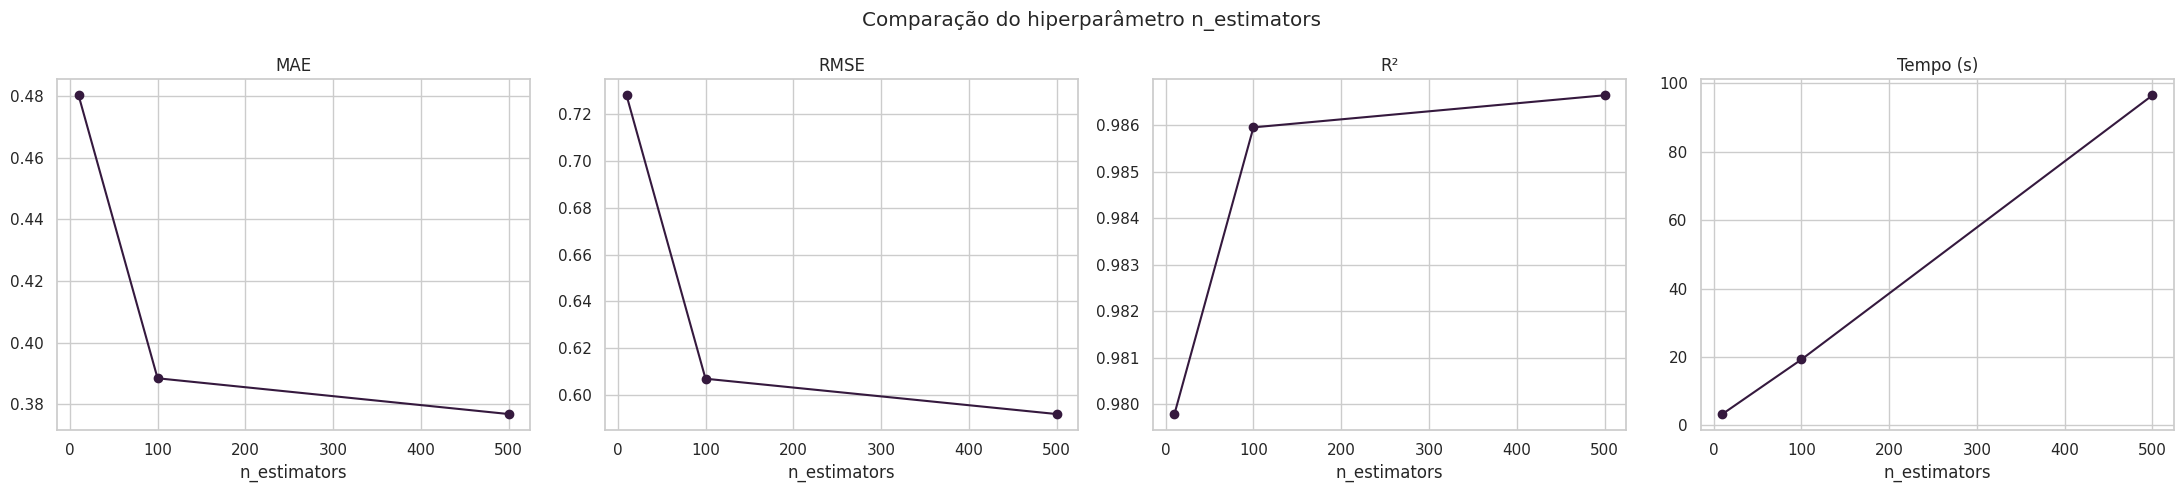

In [65]:
df_n = df_resultados_rf[df_resultados_rf['Teste'].isin(['RF-1', 'RF-2', 'RF-3'])]

fig, ax = plt.subplots(1, 4, figsize=(22,5))

ax[0].plot(df_n['n_estimators'], df_n['MAE'], marker='o')
ax[0].set_title('MAE')

ax[1].plot(df_n['n_estimators'], df_n['RMSE'], marker='o')
ax[1].set_title('RMSE')

ax[2].plot(df_n['n_estimators'], df_n['R2'], marker='o')
ax[2].set_title('R²')

ax[3].plot(df_n['n_estimators'], df_n['Tempo (s)'], marker='o')
ax[3].set_title('Tempo (s)')

for eixo in ax:
    eixo.set_xlabel('n_estimators')
    eixo.grid(True)

plt.suptitle('Comparação do hiperparâmetro n_estimators')
plt.tight_layout()
plt.show()

### Max_Features

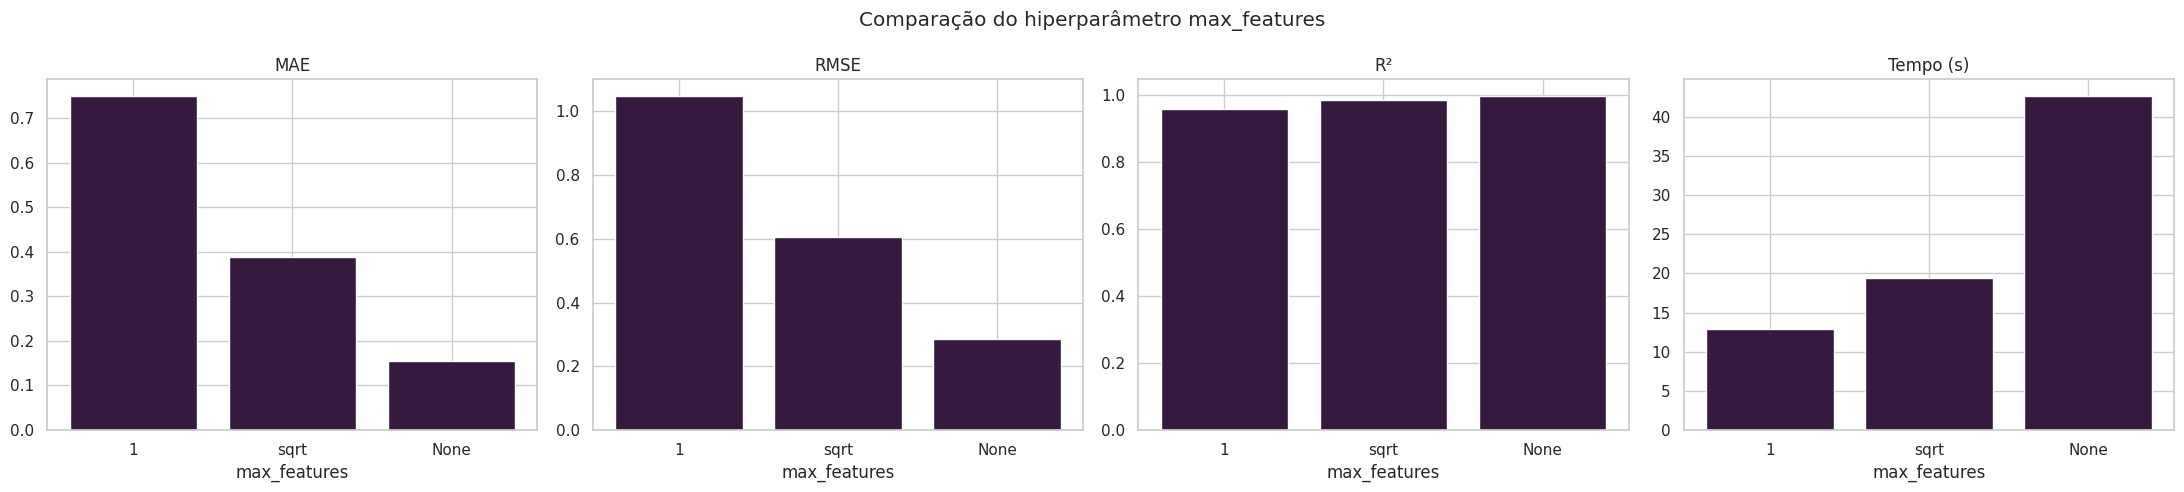

In [66]:
df_m = df_resultados_rf[df_resultados_rf['Teste'].isin(['RF-4', 'RF-5', 'RF-6'])]

fig, ax = plt.subplots(1,4, figsize=(22,5))

ax[0].bar(df_m['max_features'].astype(str), df_m['MAE'])
ax[0].set_title('MAE')

ax[1].bar(df_m['max_features'].astype(str), df_m['RMSE'])
ax[1].set_title('RMSE')

ax[2].bar(df_m['max_features'].astype(str), df_m['R2'])
ax[2].set_title('R²')

ax[3].bar(df_m['max_features'].astype(str), df_m['Tempo (s)'])
ax[3].set_title('Tempo (s)')

for eixo in ax:
    eixo.set_xlabel('max_features')

plt.suptitle('Comparação do hiperparâmetro max_features')
plt.tight_layout()
plt.show()

### Bootstrap

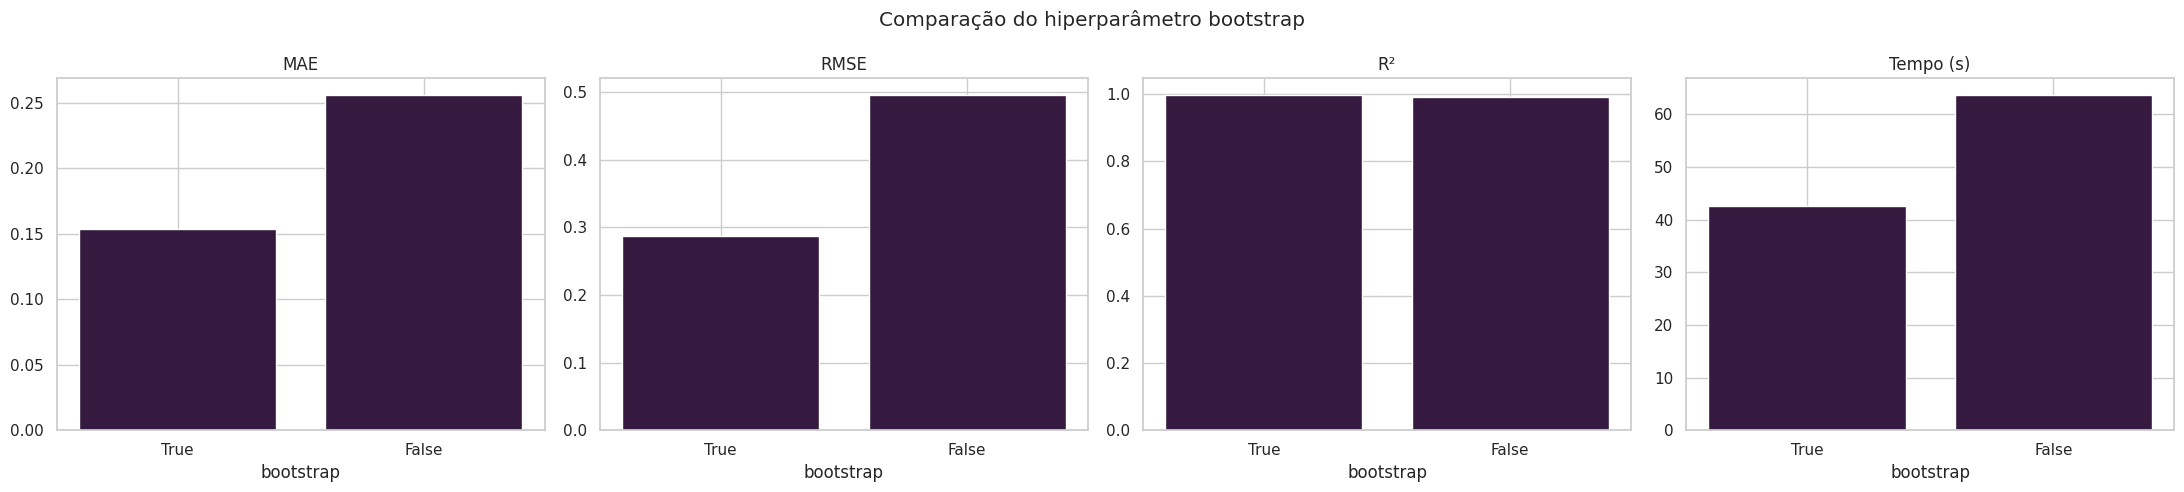

In [67]:
df_b = df_resultados_rf[df_resultados_rf['Teste'].isin(['RF-7', 'RF-8'])]

fig, ax = plt.subplots(1,4, figsize=(22,5))

ax[0].bar(df_b['bootstrap'].astype(str), df_b['MAE'])
ax[0].set_title('MAE')

ax[1].bar(df_b['bootstrap'].astype(str), df_b['RMSE'])
ax[1].set_title('RMSE')

ax[2].bar(df_b['bootstrap'].astype(str), df_b['R2'])
ax[2].set_title('R²')

ax[3].bar(df_b['bootstrap'].astype(str), df_b['Tempo (s)'])
ax[3].set_title('Tempo (s)')

for eixo in ax:
    eixo.set_xlabel('bootstrap')

plt.suptitle('Comparação do hiperparâmetro bootstrap')
plt.tight_layout()
plt.show()